

GYM CHURN PREDICTION PROJECT

### Business Problem Statement

The fitness industry faces a significant challenge in retaining members, as membership renewals are a major source of recurring revenue. Many gyms experience high customer churn due to factors such as declining engagement, dissatisfaction with services, changing personal circumstances, or competition from other fitness providers. Losing existing members not only reduces revenue but also increases the cost of acquiring new customers, making member retention a critical business objective.

Currently, many gyms rely on reactive approaches to identify members who may not renew their memberships, often only taking action after a member has already decided to leave. This limits the effectiveness of retention strategies and results in missed opportunities to engage at-risk members before they churn.

This project aims to develop a machine learning classification model that predicts whether a gym member is likely to renew their membership based on historical membership data, demographic information, attendance patterns, payment history, personal training participation, and other relevant behavioral factors. By identifying members with a high probability of non-renewal before their membership expires, gym management can implement targeted retention initiatives such as personalized promotions, loyalty rewards, fitness coaching, or customized engagement programs.

The predictive model will support data-driven decision-making by enabling the gym to proactively reduce membership churn, improve customer satisfaction, optimize marketing expenditure, and increase long-term profitability. The insights generated from the model will also help management understand the key factors influencing membership renewal, allowing them to improve service offerings and strengthen customer relationships.

### Business Objective

Develop a machine learning classification model capable of accurately predicting whether a gym member will renew their membership before it expires, enabling the business to:

* Identify members at high risk of non-renewal.
* Implement proactive retention strategies.
* Improve customer lifetime value.
* Reduce member churn and revenue loss.
* Optimize marketing and customer engagement efforts.
* Support strategic decision-making through actionable insights.

### Success Criteria

The project will be considered successful if it:

* Predicts membership renewal with a high level of accuracy and reliability.
* Identifies the most important factors influencing renewal decisions.
* Enables targeted retention campaigns for high-risk members.
* Demonstrates measurable potential to reduce churn and improve renewal rates.
* Produces a deployable model that can be integrated into the gym's decision-making process for future membership management.


In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load dataset
df= pd.read_csv("Dataset/gym_churn_messy_data.csv")

df.head()

,Subscription_Status,Age,Monthly_Fee,Avg_Class_Attendance,Check_Ins_Per_Month,Years_As_Member,Cardio_Machine_Minutes,Weight_Room_Minutes,Personal_Trainer_Sessions,Complaints_Filed,Friend_Referrals,Gender,Home_Branch,Payment_Method,Join_Date,Promo_Code_Used,Locker_Rented,Favorite_Workout_Time,Member_ID,Notes_Field
0,Renewed,36,59.99,4,8,0.2,173,177,0,3,0,F,Northside,Cash,01/01/22,WINTER20,No,Morning,GYM-42239,Requested new barbell sets
1,Expired,21,49.99,4,12,1.3,190,143,1,1,0,m,Downtown,Direct Debit,2022-01-02,NaN,No,Night,GYM-77100,Requested new barbell sets
2,Cancelled,38,59.99,5,3,1.3,139,327,0,2,0,m,Northside,Cash,2022-01-03,NaN,Y,Afternoon,GYM-49581,Prefers morning yoga
3,Cancelled,41,59.99,4,2,2.1,296,367,1,4,0,Female,Uptown,Cash,2022-01-05,NaN,Yes,Night,GYM-27866,Showers are cold
4,Renewed,40,79.99,4,4,1.3,118,306,2,0,0,femal,Downtown,Credit Card,06/01/22,NaN,No,Night,GYM-67056,Prefers morning yoga


In [8]:
#check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Subscription_Status        1000 non-null   object 
 1   Age                        1000 non-null   int64  
 2   Monthly_Fee                915 non-null    float64
 3   Avg_Class_Attendance       1000 non-null   int64  
 4   Check_Ins_Per_Month        1000 non-null   int64  
 5   Years_As_Member            1000 non-null   float64
 6   Cardio_Machine_Minutes     1000 non-null   int64  
 7   Weight_Room_Minutes        1000 non-null   int64  
 8   Personal_Trainer_Sessions  1000 non-null   int64  
 9   Complaints_Filed           1000 non-null   int64  
 10  Friend_Referrals           1000 non-null   int64  
 11  Gender                     1000 non-null   object 
 12  Home_Branch                1000 non-null   object 
 13  Payment_Method             1000 non-null   object

In [10]:
#check for duplicats
df.duplicated().sum()


0

In [11]:
df.describe()

,Age,Monthly_Fee,Avg_Class_Attendance,Check_Ins_Per_Month,Years_As_Member,Cardio_Machine_Minutes,Weight_Room_Minutes,Personal_Trainer_Sessions,Complaints_Filed,Friend_Referrals
count,1000.000000,915.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,39.812000,58.700383,3.929000,6.033000,2.021500,142.178000,197.387000,0.986000,0.824000,0.005000
std,68.851196,11.201274,1.863715,3.727977,1.975432,86.916482,116.247437,0.971982,1.196016,0.070569
min,-5.000000,49.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,49.990000,3.000000,3.000000,0.600000,67.000000,94.000000,0.000000,0.000000,0.000000
50%,35.000000,49.990000,4.000000,6.000000,1.400000,137.000000,193.500000,1.000000,0.000000,0.000000
75%,42.000000,59.990000,5.000000,9.000000,2.800000,217.250000,299.000000,2.000000,1.000000,0.000000
max,999.000000,79.990000,11.000000,16.000000,11.500000,299.000000,398.000000,5.000000,7.000000,1.000000


INITIAL FINDINGS
1. The data contains 20 columns and 1000 columns 
2. monthly fee and promo used code have missing values in them
3. There are no duplicate values in the data
4. There are 10 numerical columns and 10 categorical columns
5. The age column has a minimum value of -5 and a maxmum of 999. This suggest the presence of outliers



TARGET VARIABLE ANALYSIS

In [16]:
#move the target variable to the last end the columns

# 1. Load your dataset (replace with your actual file name)
#df = pd.read_csv("your_file.csv")

# 2. Filter out 'Subscription_Status' and append it to the end
new_column_order = [col for col in df.columns if col != "Subscription_Status"] + [
    "Subscription_Status"
]

# 3. Apply the new order to the DataFrame
df = df[new_column_order]

# View the result
df.head()


,Age,Monthly_Fee,Avg_Class_Attendance,Check_Ins_Per_Month,Years_As_Member,Cardio_Machine_Minutes,Weight_Room_Minutes,Personal_Trainer_Sessions,Complaints_Filed,Friend_Referrals,Gender,Home_Branch,Payment_Method,Join_Date,Promo_Code_Used,Locker_Rented,Favorite_Workout_Time,Member_ID,Notes_Field,Subscription_Status
0,36,59.99,4,8,0.2,173,177,0,3,0,F,Northside,Cash,01/01/22,WINTER20,No,Morning,GYM-42239,Requested new barbell sets,Renewed
1,21,49.99,4,12,1.3,190,143,1,1,0,m,Downtown,Direct Debit,2022-01-02,NaN,No,Night,GYM-77100,Requested new barbell sets,Expired
2,38,59.99,5,3,1.3,139,327,0,2,0,m,Northside,Cash,2022-01-03,NaN,Y,Afternoon,GYM-49581,Prefers morning yoga,Cancelled
3,41,59.99,4,2,2.1,296,367,1,4,0,Female,Uptown,Cash,2022-01-05,NaN,Yes,Night,GYM-27866,Showers are cold,Cancelled
4,40,79.99,4,4,1.3,118,306,2,0,0,femal,Downtown,Credit Card,06/01/22,NaN,No,Night,GYM-67056,Prefers morning yoga,Renewed


In [18]:
#check for unique features in the target variable
df['Subscription_Status'].unique()

array(['Renewed', 'Expired', 'Cancelled'], dtype=object)

In [19]:
#Standardise the column by replacing 'Expired' with 'Cancelled'
df['Subscription_Status'].replace('Expired', 'Cancelled', inplace= True)

In [21]:
#count features to check for class imbalnce
df['Subscription_Status'].value_counts()

Subscription_Status
Renewed      559
Cancelled    441
Name: count, dtype: int64

In [22]:
#check for null values. 
df['Subscription_Status'].isnull().sum()

0

1. The target variable had three unique features Renewed, Cancelled and Expired. these have been standardised into Renewed and Cancelled to make it easier to work on our classification problem.
2. The target variable is fairly balanced with 559 Renewed and 441 Cancelled with means we will not be using resampling techniques for this project
3. there are no null values in this column


UNIVARIATE ANALYSIS

In [23]:
df.head(1)

,Age,Monthly_Fee,Avg_Class_Attendance,Check_Ins_Per_Month,Years_As_Member,Cardio_Machine_Minutes,Weight_Room_Minutes,Personal_Trainer_Sessions,Complaints_Filed,Friend_Referrals,Gender,Home_Branch,Payment_Method,Join_Date,Promo_Code_Used,Locker_Rented,Favorite_Workout_Time,Member_ID,Notes_Field,Subscription_Status
0,36,59.99,4,8,0.2,173,177,0,3,0,F,Northside,Cash,01/01/22,WINTER20,No,Morning,GYM-42239,Requested new barbell sets,Renewed


In [24]:
numerical_cols = ['Age','Monthly_Fee','Avg_Class_Attendance','Check_Ins_Per_Month','Years_As_Member','Cardio_Machine_Minutes','Weight_Room_Minutes','Personal_Trainer_Sessions','Complaints_Filed','Friend_Referrals']

In [27]:
#calculate the summary statistics of the numerical data
df[numerical_cols].describe()

,Age,Monthly_Fee,Avg_Class_Attendance,Check_Ins_Per_Month,Years_As_Member,Cardio_Machine_Minutes,Weight_Room_Minutes,Personal_Trainer_Sessions,Complaints_Filed,Friend_Referrals
count,1000.000000,915.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,39.812000,58.700383,3.929000,6.033000,2.021500,142.178000,197.387000,0.986000,0.824000,0.005000
std,68.851196,11.201274,1.863715,3.727977,1.975432,86.916482,116.247437,0.971982,1.196016,0.070569
min,-5.000000,49.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,49.990000,3.000000,3.000000,0.600000,67.000000,94.000000,0.000000,0.000000,0.000000
50%,35.000000,49.990000,4.000000,6.000000,1.400000,137.000000,193.500000,1.000000,0.000000,0.000000
75%,42.000000,59.990000,5.000000,9.000000,2.800000,217.250000,299.000000,2.000000,1.000000,0.000000
max,999.000000,79.990000,11.000000,16.000000,11.500000,299.000000,398.000000,5.000000,7.000000,1.000000


1. The age column has a minimum value of -5 and a maxmum of 999. This suggest the presence of outliers. it also has a mean age of 39 and a median of 35
2. Monthly fee column has a mean of 58.7 and a median of 49.99. it also has a count of 915 with suggest there are missing values in the columns

In [28]:
#confirm missing data in monthly fee column
df['Monthly_Fee'].isnull().sum()

85

There are 85 missing data in the monthly fee column

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   Monthly_Fee                915 non-null    float64
 2   Avg_Class_Attendance       1000 non-null   int64  
 3   Check_Ins_Per_Month        1000 non-null   int64  
 4   Years_As_Member            1000 non-null   float64
 5   Cardio_Machine_Minutes     1000 non-null   int64  
 6   Weight_Room_Minutes        1000 non-null   int64  
 7   Personal_Trainer_Sessions  1000 non-null   int64  
 8   Complaints_Filed           1000 non-null   int64  
 9   Friend_Referrals           1000 non-null   int64  
 10  Gender                     1000 non-null   object 
 11  Home_Branch                1000 non-null   object 
 12  Payment_Method             1000 non-null   object 
 13  Join_Date                  1000 non-null   object

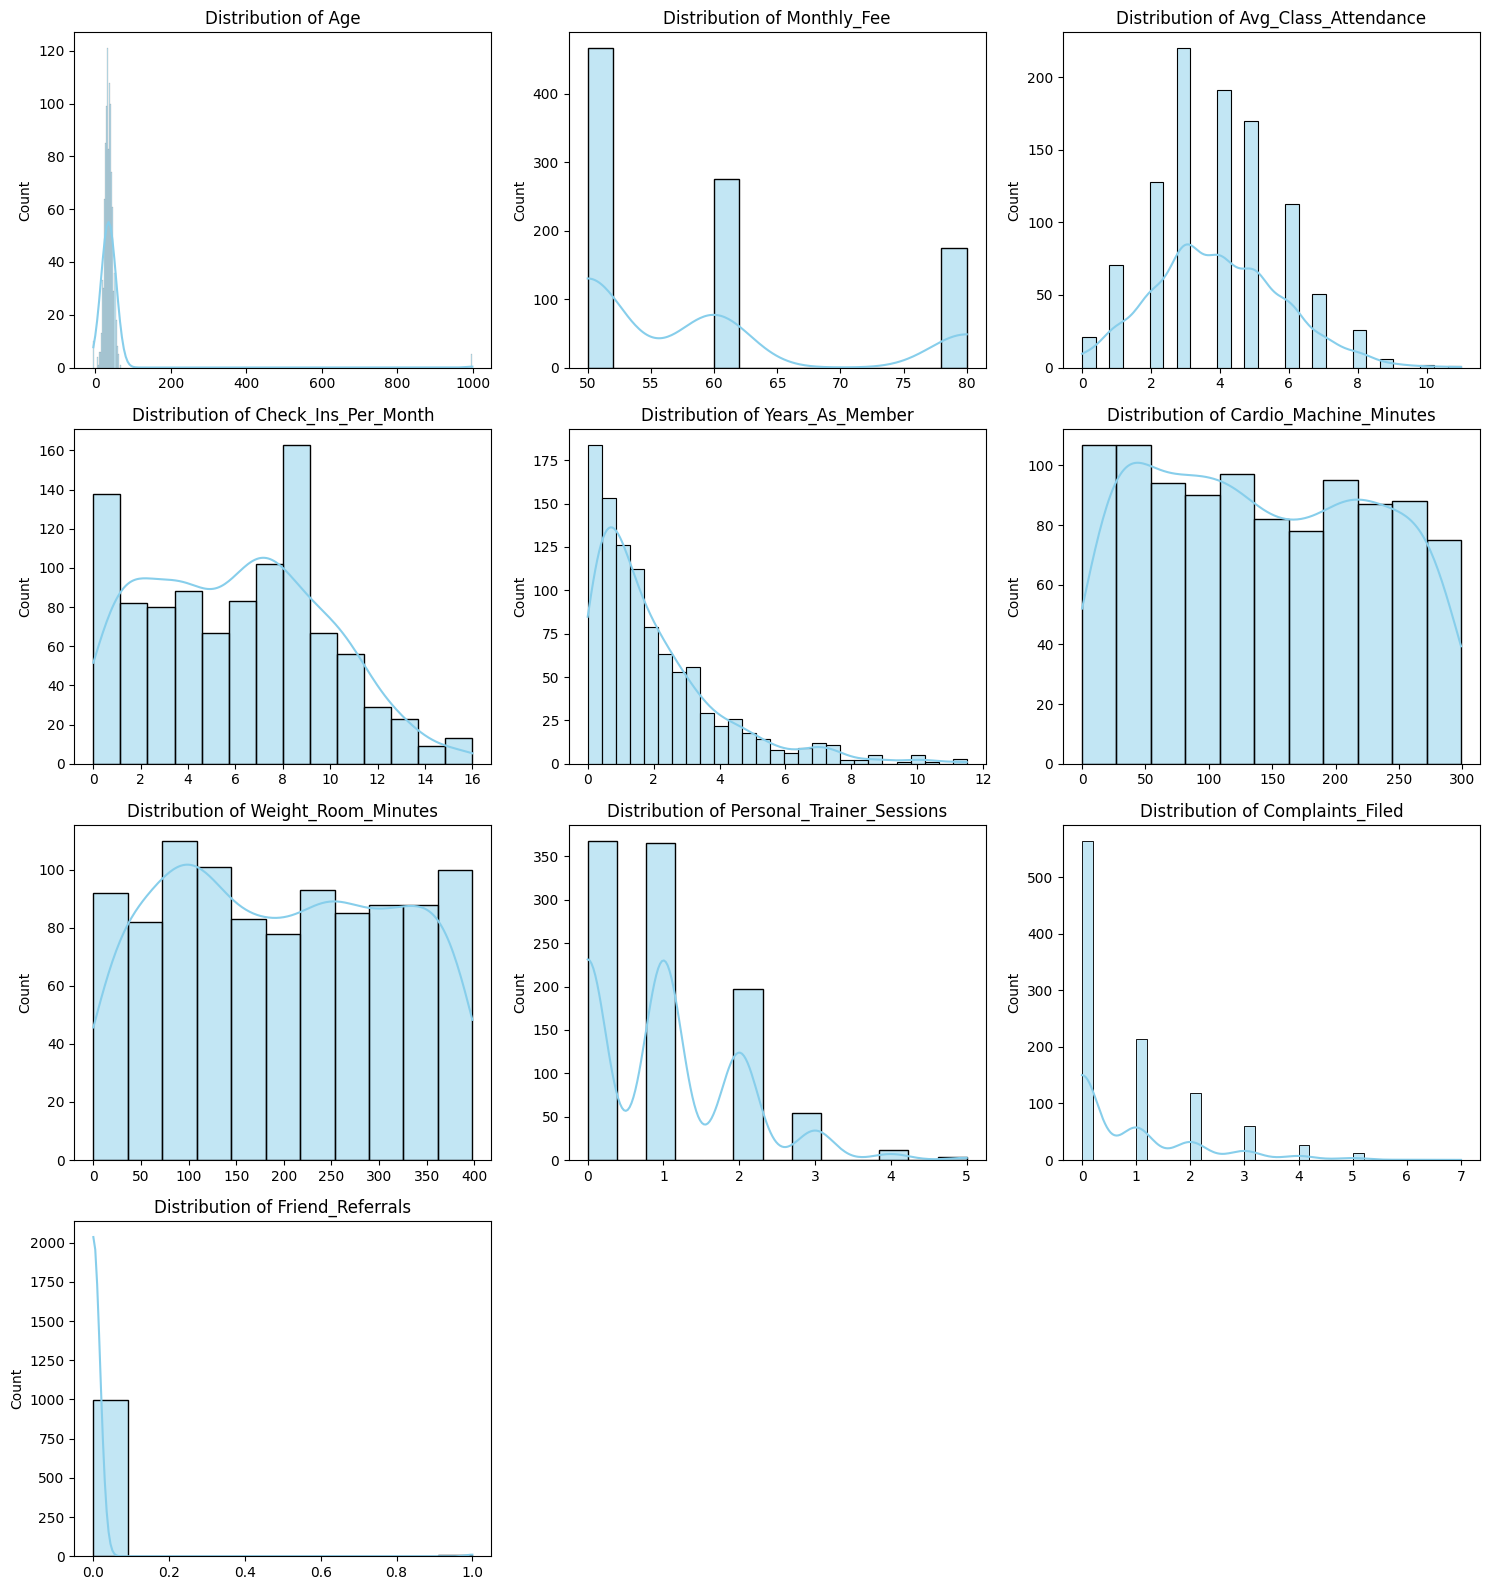

In [ ]:
#check for the skewness of the data
# 1. Automatically grab all numerical columns
# Excludes ID columns if they are read as numbers
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "Member_ID" in num_cols:
    num_cols.remove("Member_ID")

# 2. Define grid dimensions dynamically based on column count
n_cols = 3  # Set how many plots you want per row
n_rows = int(np.ceil(len(num_cols) / n_cols))

# 3. Create the figure grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()  # Flatten to easily loop with a single index

# 4. Loop through columns and plot histograms
for i, col in enumerate(num_cols):
    sns.histplot(
        data=df, x=col, kde=True, ax=axes[i], color="skyblue", edgecolor="black"
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel("")  # Cleans up the axis label clutter
    axes[i].set_ylabel("Count")

# 5. Hide any unused empty subplots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Adjust layout and display
plt.tight_layout()
plt.show()


1. The age and referall columns are skewed to the right. this means that the data points are concentrated on the left.
2. The monthly fee, personal trainer session and complaints filed columns are  skewed to the right however its data points are widely spread indicating high variability
3. The age columns is normally distributed with data widely spread indicating high viriability. it is also bell shaped which means the mean, median and mode are roughly equal
4. Distribution of check ins per month shows a bimodal distribution with high variance
5. Distribution of years as a member heavily skewed to the right with high viriability
6. cardio machine minutes and weight room minutes are roughly uniformly distributed

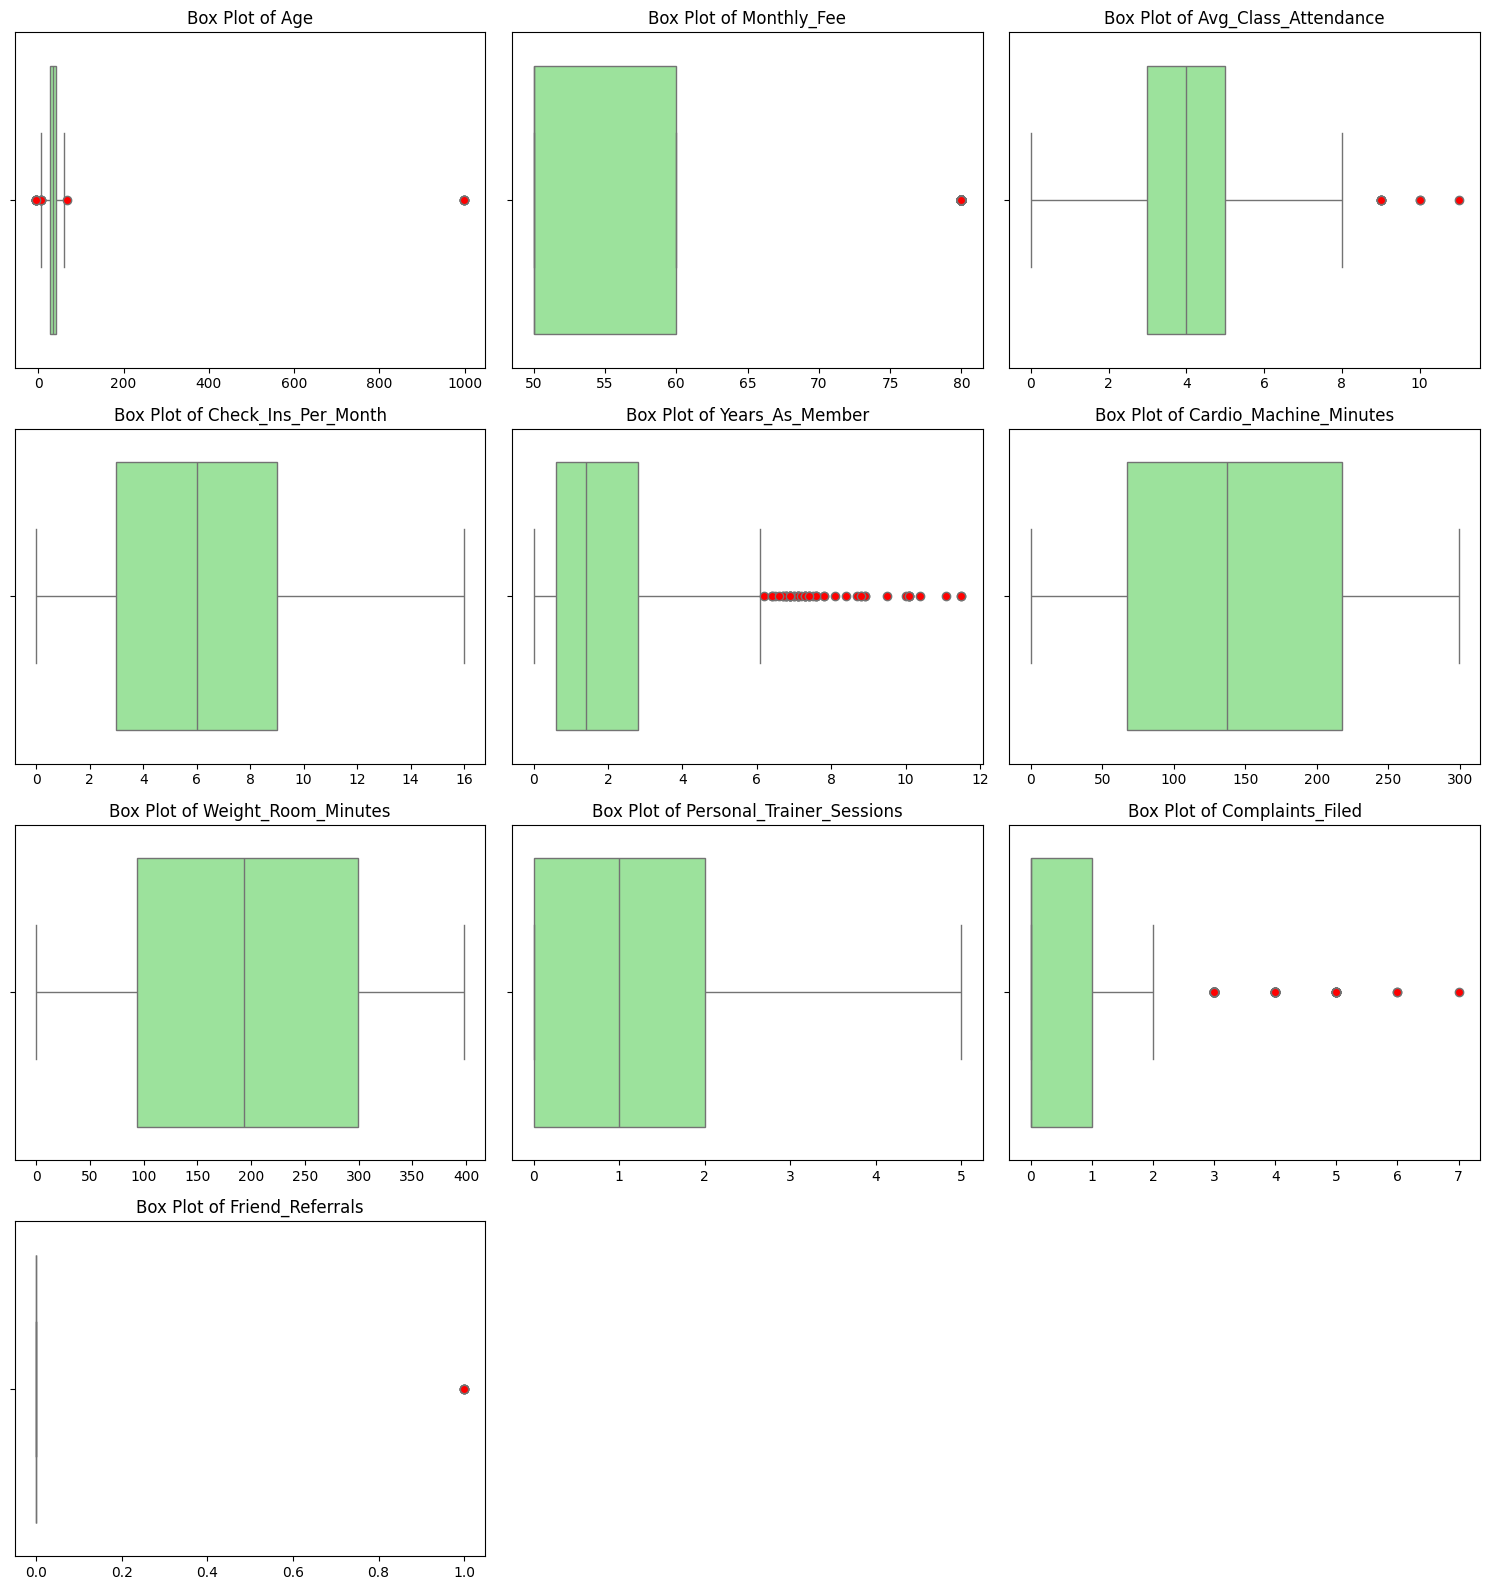

In [32]:
#Check for outliers using boxplots


# 1. Automatically grab all numerical columns (excluding ID codes)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "Member_ID" in num_cols:
    num_cols.remove("Member_ID")

# 2. Define grid dimensions dynamically (3 plots per row)
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

# 3. Create the figure grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()  # Flatten to iterate with a single loop index

# 4. Loop through columns and plot horizontal box plots
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i],
        color="lightgreen",
        flierprops={"markerfacecolor": "red", "marker": "o"},
    )
    axes[i].set_title(f"Box Plot of {col}", fontsize=12)
    axes[i].set_xlabel("")  # Cleans up label clutter

# 5. Hide any unused empty subplots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Adjust layout and display
plt.tight_layout()
plt.show()


The age, monthly fee, average class attendance,year as a member,complaints filed and friend referrals appears to have outliers in them. further investigations will be conducted

In [34]:
# Select categorical columns
cat_cols = ['Gender', 'Home_Branch', 'Payment_Method', 'Promo_Code_Used']

# Print unique values and check for anomalies
for col in cat_cols:
    print(f"{col} unique values: {df[col].unique()}")


Gender unique values: ['F' 'm' 'Female' 'femal' 'Male' 'M']
Home_Branch unique values: ['Northside' 'Downtown' 'Uptown']
Payment_Method unique values: ['Cash' 'Direct Debit' 'Credit Card']
Promo_Code_Used unique values: ['WINTER20' nan 'SUMMER50']


In [36]:
#Standardise categorical  columns
df['Gender'].replace(['F','femal' ], 'Female', inplace= True)
df['Gender'].replace(['m','M' ], 'Female', inplace= True)

In [38]:
# Get absolute counts and percentage distribution
for col in cat_cols:
    print(f"\n--- Frequency for {col} ---")
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    
    # Combine into a clean summary table
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
    print(summary)



--- Frequency for Gender ---
        Count  Percentage (%)
Gender                       
Female    848            84.8
Male      152            15.2

--- Frequency for Home_Branch ---
             Count  Percentage (%)
Home_Branch                       
Northside      369            36.9
Downtown       316            31.6
Uptown         315            31.5

--- Frequency for Payment_Method ---
                Count  Percentage (%)
Payment_Method                       
Direct Debit      338            33.8
Cash              335            33.5
Credit Card       327            32.7

--- Frequency for Promo_Code_Used ---
                 Count  Percentage (%)
Promo_Code_Used                       
WINTER20           100       68.965517
SUMMER50            45       31.034483


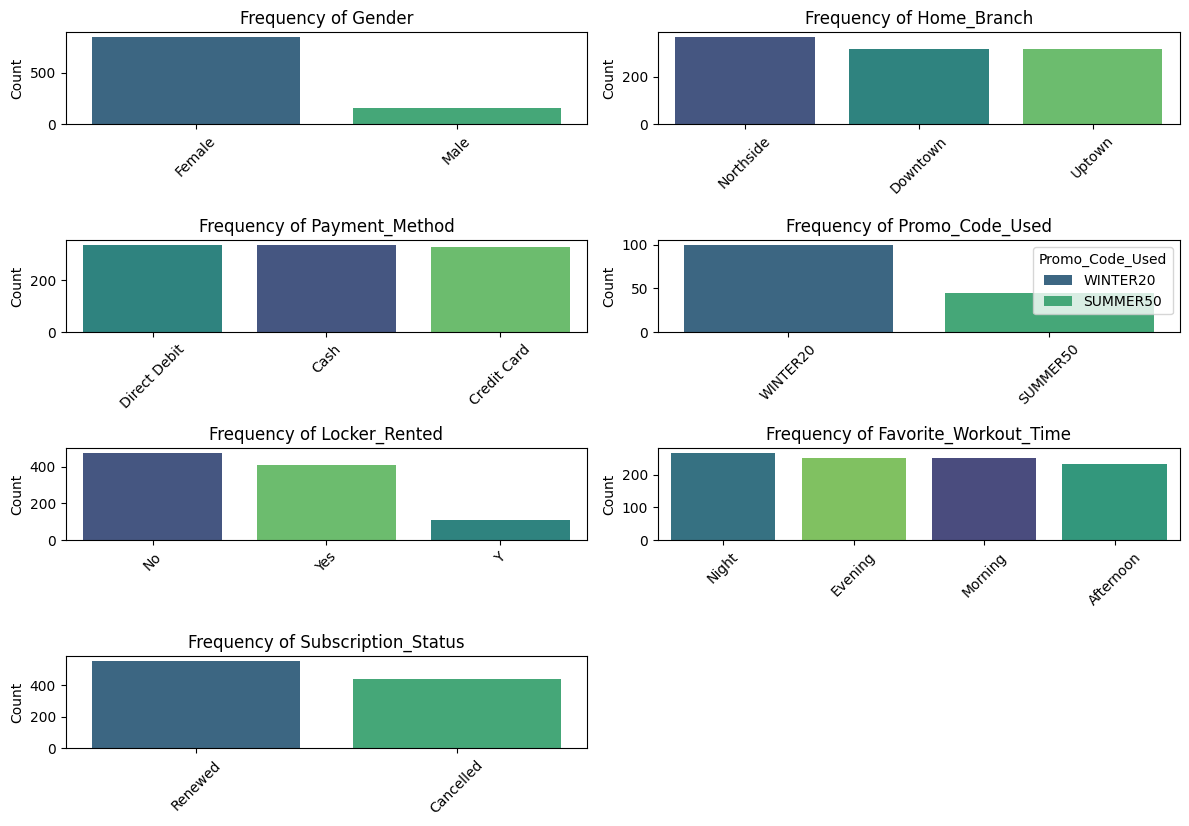

In [ ]:


# 1. Automatically grab categorical columns (excluding unique ID/Notes text)
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Drop columns with high cardinality that would ruin a count plot
cols_to_exclude = ["Member_ID", "Notes_Field", "Join_Date"]
cat_cols = [col for col in cat_cols if col not in cols_to_exclude]

# 2. Define grid dimensions dynamically (2 plots per row works best for text)
n_cols = 2
n_rows = int(np.ceil(len(cat_cols) / n_cols))

# 3. Create the figure grid
fig, axes = plt.subplots(n_cols * n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4))
axes = axes.flatten()

# 4. Loop through columns and plot count plots
for i, col in enumerate(cat_cols):
    # Order bars from highest frequency to lowest for cleaner scanning
    order = df[col].value_counts().index

    sns.countplot(
        data=df, x=col, ax=axes[i], order=order, palette="viridis", hue=col
    )

    axes[i].set_title(f"Frequency of {col}", fontsize=12)
    axes[i].set_xlabel("")  # Removes redundant bottom label
    axes[i].set_ylabel("Count")

    # Rotate X-axis labels if text categories are long
    axes[i].tick_params(axis="x", labelrotation=45)

# 5. Hide any unused empty subplots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Adjust layout and display
plt.tight_layout()
plt.show()
